# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Nama Dataset: Telco Customer Churn

Sumber: Kaggle Repositories

Deskripsi: Dataset ini berisi informasi pelanggan fiktif dari perusahaan telekomunikasi, termasuk status apakah mereka berhenti berlangganan (Churn) atau menetap.

Tujuan: Memprediksi perilaku pelanggan untuk meminimalkan kehilangan konsumen.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

# Mengatur estetika plot visualisasi
sns.set_theme(style="whitegrid")
print("Library berhasil di-import!")

Library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Mengambil dataset langsung dari URL publik raw GitHub
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Menampilkan 5 baris pertama data
print("Ukuran Dataset:", df.shape)
df.head()

Ukuran Dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Informasi Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessB

C:\Users\ucha\AppData\Local\Temp\ipykernel_21372\1336643723.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


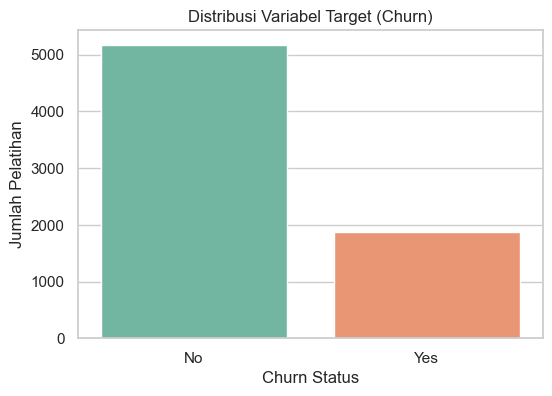

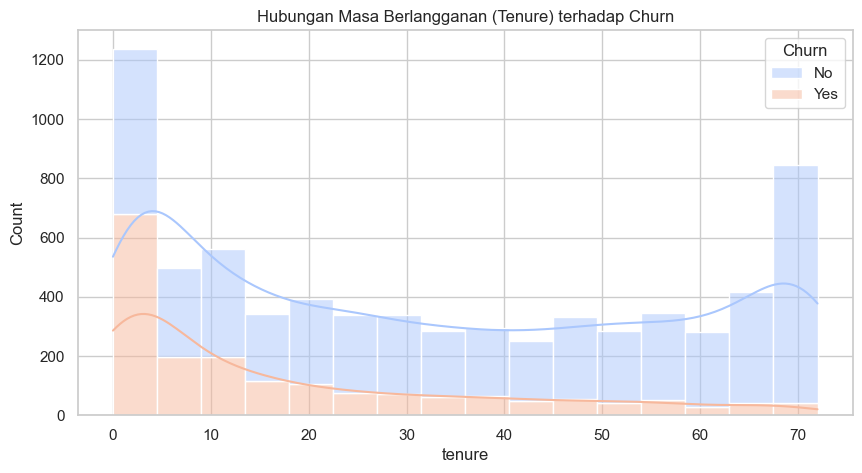

In [3]:
# 1. Cek info struktur data dan tipe data komponen
print("--- Informasi Struktur Data ---")
df.info()

# 2. Cek apakah ada nilai kosong secara umum
print("\n--- Jumlah Nilai Kosong per Kolom ---")
print(df.isnull().sum())

# 3. Cek deskripsi statistik untuk fitur numerik
print("\n--- Deskripsi Statistik ---")
print(df.describe())

# 4. Analisis Kolom 'TotalCharges' yang bertipe objek padahal seharusnya numerik
print("\n--- Cek keanehan pada TotalCharges ---")
# Menemukan baris dengan spasi kosong pada kolom TotalCharges
empty_total_charges = df[df['TotalCharges'].str.contains(' ')]
print(f"Jumlah baris dengan spasi kosong pada TotalCharges: {len(empty_total_charges)}")

# 5. Visualisasi Distribusi Target Variabel (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribusi Variabel Target (Churn)')
plt.xlabel('Churn Status')
plt.ylabel('Jumlah Pelatihan')
plt.show()

# 6. Visualisasi Hubungan Antara Tenure (Lama Berlangganan) dan Churn
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', kde=True, palette='coolwarm')
plt.title('Hubungan Masa Berlangganan (Tenure) terhadap Churn')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# Membuat duplikat agar data asli aman
df_clean = df.copy()

# 1. Drop kolom 'customerID' karena tidak memiliki bobot prediksi
df_clean.drop(columns=['customerID'], inplace=True)

# 2. Menangani nilai kosong tersembunyi (spasi) pada 'TotalCharges'
df_clean['TotalCharges'] = df_clean['TotalCharges'].replace(' ', np.nan)

# Mengubah tipe datanya menjadi float numerik
df_clean['TotalCharges'] = df_clean['TotalCharges'].astype(float)

# Perbaikan Chained Assignment (Pandas 3.0+): Menghapus inplace=True dan langsung assignment kembali
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())

# 3. Encoding Data Kategorikal (Mengubah teks teks menjadi angka numerik)
le = LabelEncoder()
categorical_cols = df_clean.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# 4. Memisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

# 5. Splitting Data (80% Train, 20% Test)
# PERBAIKAN: Mengubah 'test_split' menjadi 'test_size'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Standardisasi / Penskalaan Nilai Fitur Numerik
# Menggunakan .loc untuk menghindari SettingWithCopyWarning saat transformasi nilai
scaler = StandardScaler()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train.loc[:, numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test.loc[:, numerical_cols] = scaler.transform(X_test[numerical_cols])

# 7. Menyimpan Output Hasil Preprocessing untuk Kriteria Selanjutnya
os.makedirs('namadataset_preprocessing', exist_ok=True)
X_train.to_csv('namadataset_preprocessing/X_train.csv', index=False)
X_test.to_csv('namadataset_preprocessing/X_test.csv', index=False)
y_train.to_csv('namadataset_preprocessing/y_train.csv', index=False)
y_test.to_csv('namadataset_preprocessing/y_test.csv', index=False)

print("Proses preprocessing selesai tanpa error! Semua file berhasil disimpan.")

Proses preprocessing selesai tanpa error! Semua file berhasil disimpan.


C:\Users\ucha\AppData\Local\Temp\ipykernel_21372\3929200110.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.10237124 -0.71174346 -0.79315493 ... -0.30468611 -0.34539184
 -1.07809507]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
C:\Users\ucha\AppData\Local\Temp\ipykernel_21372\3929200110.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.60848343 -0.9966836   0.34660565 ... -1.11880081  0.95719167
  1.60848343]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_test.loc[:, numerical_cols] = scaler.transform(X_test[numerical_cols])
